In [2]:
# # Oasis Infobyte Internship

# ## Level 1 - Task 4

# # Sentiment Analysis using Machine Learning

# **Name:** Jigyasha Jain

# ## Objective

# To build a machine learning model that classifies text into Positive, Negative, or Neutral sentiment using Natural Language Processing (NLP) techniques.

In [5]:
pip install wordcloud

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
from wordcloud import WordCloud

print("WordCloud Installed Successfully!")

WordCloud Installed Successfully!


In [8]:
import sys
print(sys.executable)

C:\Users\hp\AppData\Local\Programs\Python\Python313\python.exe


In [9]:
from wordcloud import WordCloud

print("WordCloud Installed Successfully!")

WordCloud Installed Successfully!


In [12]:
import pandas as pd

df = pd.read_csv(
    "twitter_training.csv.zip",
    header=None,
    names=["ID", "Entity", "Sentiment", "Text"]
)

In [13]:
df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [14]:
df.head()

,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [15]:
df.shape

(74682, 4)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [17]:
df.isnull().sum()

ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64

In [19]:
# ## Initial Inspection

# The Twitter Sentiment dataset was loaded successfully. The dataset contains tweet text along with sentiment labels. Missing values and data types were inspected before preprocessing.

In [20]:
df.dropna(subset=["Text"], inplace=True)

df.isnull().sum()

ID           0
Entity       0
Sentiment    0
Text         0
dtype: int64

In [21]:
df["Sentiment"].value_counts()

Sentiment
Negative      22358
Positive      20655
Neutral       18108
Irrelevant    12875
Name: count, dtype: int64

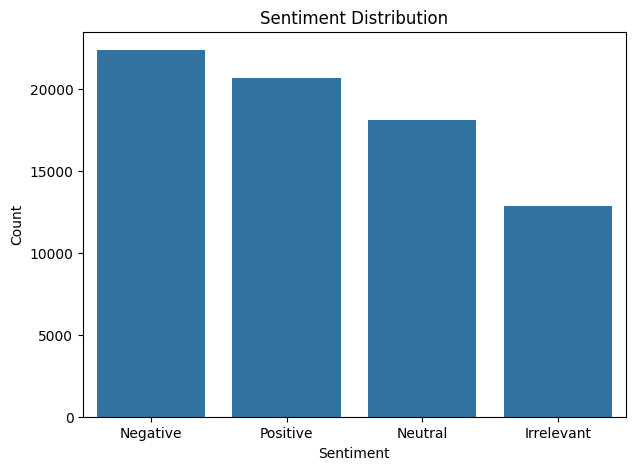

In [22]:
plt.figure(figsize=(7,5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=df["Sentiment"].value_counts().index
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [24]:
# ## Observation

# The dataset contains multiple sentiment classes. The sentiment distribution provides insight into whether the dataset is balanced before model training.

In [25]:
import nltk

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\hp\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [26]:
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

In [27]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [28]:
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [29]:
def clean_text(text):

    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenization
    words = text.split()

    # Remove stopwords + lemmatize
    words = [
        lemmatizer.lemmatize(word)
        for word in words
        if word not in stop_words
    ]

    return " ".join(words)

In [30]:
df["Clean_Text"] = df["Text"].apply(clean_text)

In [31]:
df[["Text", "Clean_Text"]].head()

,Text,Clean_Text
0,im getting on borderlands and i will murder yo...,im getting borderland murder
1,I am coming to the borders and I will kill you...,coming border kill
2,im getting on borderlands and i will kill you ...,im getting borderland kill
3,im coming on borderlands and i will murder you...,im coming borderland murder
4,im getting on borderlands 2 and i will murder ...,im getting borderland murder


In [33]:
# ## Text Preprocessing

# The text preprocessing pipeline included:

# - Converting text to lowercase
# - Removing URLs
# - Removing numbers
# - Removing punctuation
# - Tokenization
# - Stopword removal
# - Lemmatization

# These preprocessing steps improve the quality of textual data before feature extraction using TF-IDF.

In [35]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(max_features=5000)

X = vectorizer.fit_transform(df["Clean_Text"])

y = df["Sentiment"]

In [36]:
# ## TF-IDF Vectorizer

# TF-IDF (Term Frequency–Inverse Document Frequency) converts text into numerical vectors that machine learning models can understand.

# It assigns higher importance to meaningful words while reducing the weight of very common words that appear frequently across documents.

In [37]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [38]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

In [39]:
from sklearn.metrics import accuracy_score, classification_report

print("Naive Bayes Accuracy:", accuracy_score(y_test, nb_pred))

print(classification_report(y_test, nb_pred))

Naive Bayes Accuracy: 0.6316891891891891
              precision    recall  f1-score   support

  Irrelevant       0.75      0.34      0.47      2696
    Negative       0.62      0.81      0.70      4380
     Neutral       0.66      0.52      0.58      3605
    Positive       0.60      0.74      0.66      4119

    accuracy                           0.63     14800
   macro avg       0.66      0.60      0.60     14800
weighted avg       0.65      0.63      0.62     14800



In [40]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

In [41]:
print("Logistic Regression Accuracy:", accuracy_score(y_test, lr_pred))

print(classification_report(y_test, lr_pred))

Logistic Regression Accuracy: 0.6825675675675675
              precision    recall  f1-score   support

  Irrelevant       0.70      0.51      0.59      2696
    Negative       0.72      0.78      0.75      4380
     Neutral       0.63      0.65      0.64      3605
    Positive       0.68      0.73      0.70      4119

    accuracy                           0.68     14800
   macro avg       0.68      0.66      0.67     14800
weighted avg       0.68      0.68      0.68     14800



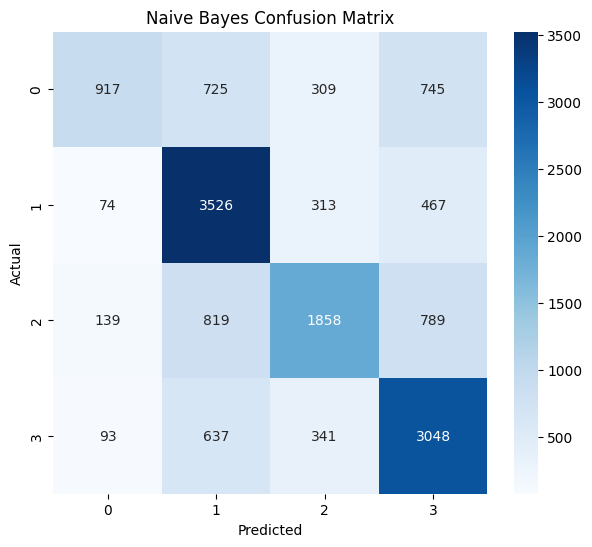

In [42]:
from sklearn.metrics import confusion_matrix

plt.figure(figsize=(7,6))

sns.heatmap(
    confusion_matrix(y_test, nb_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

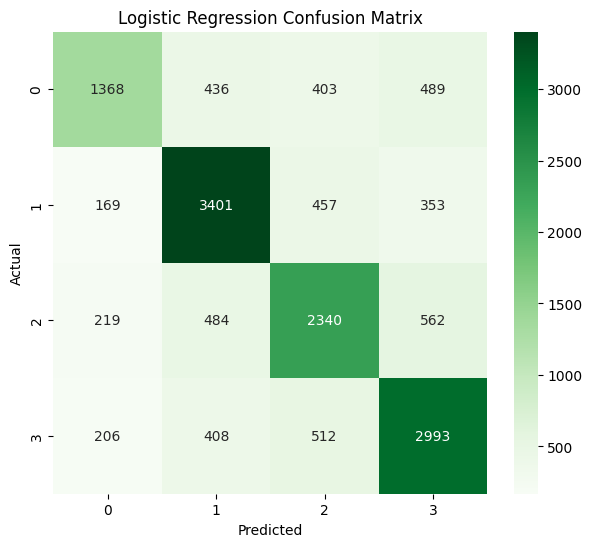

In [43]:
plt.figure(figsize=(7,6))

sns.heatmap(
    confusion_matrix(y_test, lr_pred),
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Logistic Regression Confusion Matrix")

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [46]:
print(df["Sentiment"].unique())

['Positive' 'Neutral' 'Negative' 'Irrelevant']


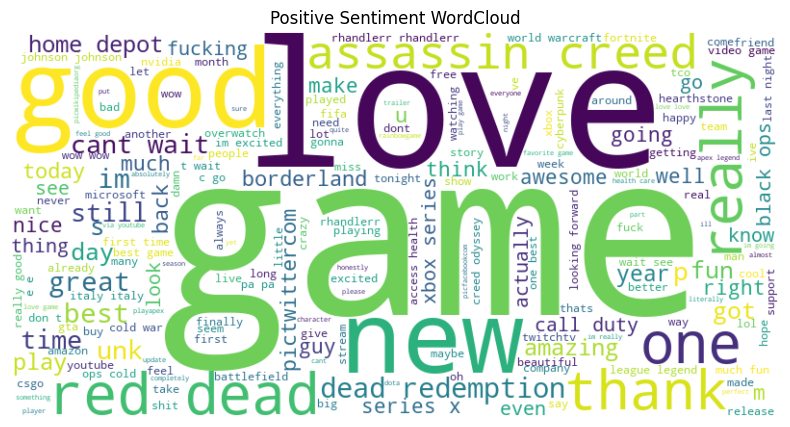

In [47]:
positive_text = " ".join(df[df["Sentiment"]=="Positive"]["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(positive_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Positive Sentiment WordCloud")
plt.show()

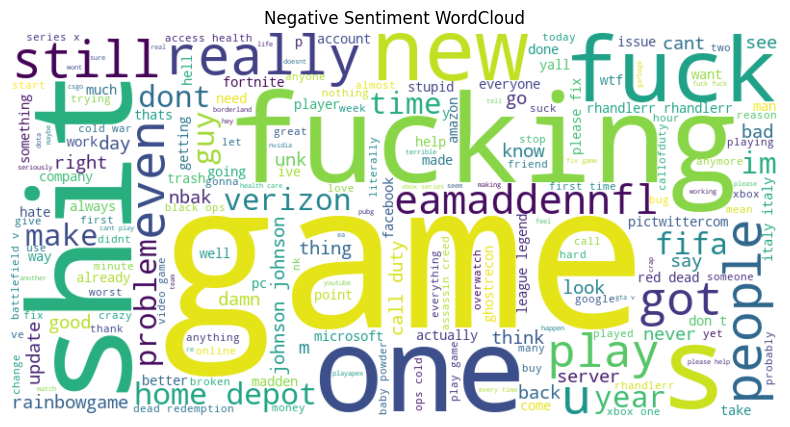

In [48]:
negative_text = " ".join(df[df["Sentiment"]=="Negative"]["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(negative_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Negative Sentiment WordCloud")
plt.show()

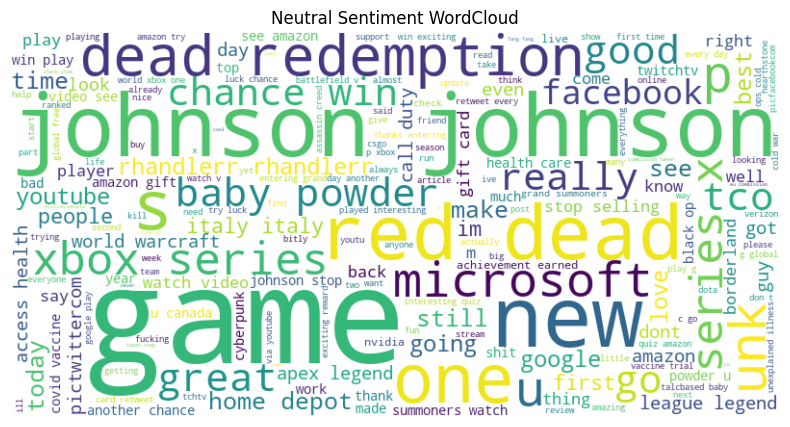

In [49]:
neutral_text = " ".join(df[df["Sentiment"]=="Neutral"]["Clean_Text"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(neutral_text)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Neutral Sentiment WordCloud")
plt.show()

In [50]:
errors = pd.DataFrame({
    "Text": df.loc[y_test.index, "Text"],
    "Actual": y_test,
    "Predicted": lr_pred
})

misclassified = errors[
    errors["Actual"] != errors["Predicted"]
]

misclassified.head(5)

,Text,Actual,Predicted
2308,SO I HAPPY WHO ABOUT THIS.,Negative,Positive
29659,I'm back!,Neutral,Positive
56006,Boy oh boy do I love kaid shotty.. •. •. •. •....,Neutral,Irrelevant
28505,Solo and when shit fucking rages - Part 2.. re...,Neutral,Negative
10701,"Death Tales gif won the day,",Irrelevant,Neutral


In [51]:
# ## Error Analysis

# The model misclassified some tweets due to:

# - Mixed or ambiguous sentiment in the text.
# - Informal language, abbreviations, and slang commonly used on Twitter.
# - Lack of contextual understanding, such as sarcasm or irony.
# - Similar wording across different sentiment classes.

# These limitations are common in traditional machine learning models and could be improved using advanced deep learning approaches such as LSTM or Transformer-based models.

In [52]:
# # Conclusion

# In this project, a sentiment analysis model was developed using Natural Language Processing (NLP) and Machine Learning techniques.

# ### Key Steps Performed
# - Loaded and explored the Twitter Sentiment dataset.
# - Preprocessed text by converting it to lowercase, removing punctuation, removing stopwords, and applying lemmatization.
# - Converted text into numerical features using the TF-IDF Vectorizer.
# - Split the dataset into training and testing sets (80/20).
# - Trained two classifiers: Naive Bayes and Logistic Regression.
# - Evaluated both models using accuracy, precision, recall, F1-score, and confusion matrices.
# - Visualized the sentiment distribution and generated WordClouds for different sentiment classes.
# - Performed error analysis by reviewing misclassified tweets.

# ### Model Comparison

# | Model | Accuracy |
# |--------|----------|
# | Naive Bayes | **63.17%** |
# | Logistic Regression | **68.26%** |

# Logistic Regression achieved the best performance and is recommended for this dataset.

# ### Real-World Applications

# This sentiment analysis system can be used for:
# - Customer feedback analysis
# - Product review classification
# - Brand reputation monitoring
# - Social media sentiment tracking
# - Public opinion analysis